# CUSTOMER CHURN PREDICTION
- PHASE 1 : ENVIRONMENT SETUP


In [1]:

# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

import joblib

print("="*60)
print("Libraries Imported Successfully")
print("="*60)

# ==========================================================
# Project Paths
# ==========================================================
os.makedirs("../charts",exist_ok=True)
print("successfullly created charts")
DATASET_PATH = "../dataset/customer_churn.csv"

MODEL_PATH = "../model/churn_model.pkl"

SCALER_PATH = "../model/scaler.pkl"

print("Dataset :", DATASET_PATH)
print("Model :", MODEL_PATH)
print("Scaler :", SCALER_PATH)

print("="*60)
print("Environment Setup Completed Successfully")
print("="*60)


Libraries Imported Successfully
successfullly created charts
Dataset : ../dataset/customer_churn.csv
Model : ../model/churn_model.pkl
Scaler : ../model/scaler.pkl
Environment Setup Completed Successfully


- PHASE 2 : DATASET COLLECTION



In [2]:
df = pd.read_csv(DATASET_PATH)

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

display(df.head())

print("="*60)
print("Dataset Shape")
print("="*60)

print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

print("="*60)
print("Statistical Summary")
print("="*60)

display(df.describe(include="all"))

print("="*60)
print("Dataset Columns")
print("="*60)

df.columns.tolist()


print("="*60)
print("Target Variable")
print("="*60)

display(df["Churn"].value_counts())

display(df["Churn"].value_counts(normalize=True) * 100)

print("="*60)
print("Missing Values")
print("="*60)

display(df.isnull().sum())

print("="*60)
print("Duplicate Rows")
print("="*60)

print(df.duplicated().sum())



display(df.sample(10))
print("="*60)
print("Dataset Summary")
print("="*60)

print(f"Total Records : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")
print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicate Rows : {df.duplicated().sum()}")

Dataset Loaded Successfully


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dataset Shape
Rows : 7043
Columns : 21
Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-nul

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


Dataset Columns
Target Variable


...

Missing Values


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows
0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1639,4690-LLKUA,Male,1,No,No,17,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,45.05,770.6,Yes
5058,1376-HHBDV,Female,0,No,No,30,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,48.80,1536.75,No
2738,2351-BKRZW,Female,0,Yes,Yes,43,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),75.20,3254.35,No
2206,3207-OYBWH,Male,1,Yes,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),95.25,5427.05,Yes
361,5229-DTFYB,Female,0,No,No,41,Yes,No,Fiber optic,No,...,No,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),98.80,3959.15,No
5526,6546-OPBBH,Male,0,Yes,Yes,51,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,23.95,1216.35,No
2072,5986-WWXDV,Male,0,No,Yes,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),19.35,779.2,No
3341,1125-SNVCK,Female,1,No,No,49,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,43.80,2106.05,No
6607,7242-QZLXF,Male,0,No,Yes,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,25.30,25.3,Yes
6872,5297-MDOIR,Female,0,Yes,No,63,Yes,No,Fiber optic,Yes,...,Yes,No,No,No,One year,Yes,Credit card (automatic),81.15,5224.5,No


Dataset Summary
Total Records : 7043
Total Columns : 21
Missing Values : 0
Duplicate Rows : 0


- Phase 3: Data Cleaning & Preprocessing

In [3]:
# ==========================================================
# PHASE 3 : DATA CLEANING
# ==========================================================

# Create a copy
df_clean = df.copy()

# Remove Customer ID
df_clean.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

# Check Missing Values
print("="*60)
print("Missing Values")
print("="*60)

print(df_clean.isnull().sum())

# Fill Missing Values
df_clean["TotalCharges"].fillna(
    df_clean["TotalCharges"].median(),
    inplace=True
)

# Remove Duplicate Rows
df_clean.drop_duplicates(inplace=True)

print("\nDataset Shape :", df_clean.shape)

display(df_clean.head())

Missing Values
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Dataset Shape : (7021, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# ==========================================================
# Encoding
# ==========================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

binary_columns = [

    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"

]

for column in binary_columns:

    df_clean[column] = label_encoder.fit_transform(
        df_clean[column]
    )

# One-Hot Encoding
df_clean = pd.get_dummies(
    df_clean,
    drop_first=True
)

print("="*60)
print("Encoding Completed")
print("="*60)

display(df_clean.head())

Encoding Completed


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [5]:
# ==========================================================
# Feature Scaling
# ==========================================================

from sklearn.preprocessing import StandardScaler

X = df_clean.drop("Churn", axis=1)

y = df_clean["Churn"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("="*60)
print("Scaling Completed")
print("="*60)

print("Features Shape :", X_scaled.shape)

print("Target Shape :", y.shape)

Scaling Completed
Features Shape : (7021, 30)
Target Shape : (7021,)


In [6]:
# ==========================================================
# Train Test Split
# ==========================================================

from sklearn.model_selection import train_test_split
import joblib

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("="*60)
print("Train Test Split")
print("="*60)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

# Save Scaler
joblib.dump(
    scaler,
    "../model/scaler.pkl"
)

print("\nScaler Saved Successfully")

Train Test Split
Training Samples : (5616, 30)
Testing Samples : (1405, 30)

Scaler Saved Successfully


In [7]:
# ==========================================================
# Save Processed Dataset
# ==========================================================

processed_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

processed_df["Churn"] = y.values

processed_df.to_csv(
    "../dataset/processed_customer_churn.csv",
    index=False
)

print("="*60)
print("Processed Dataset Saved Successfully")
print("="*60)

display(processed_df.head())

Processed Dataset Saved Successfully


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,-1.008726,-0.440508,1.031400,-0.655475,-1.282728,-3.048725,0.829057,-1.164135,-0.997328,3.048725,...,-0.523889,-0.792144,-0.523889,-0.798109,-0.515268,-0.564137,-0.526097,1.405796,-0.542396,0
1,0.991349,-0.440508,-0.969556,-0.655475,0.062387,0.328006,-1.206190,-0.262811,-0.176347,-0.328006,...,-0.523889,-0.792144,-0.523889,-0.798109,1.940738,-0.564137,-0.526097,-0.711341,1.843671,0
2,0.991349,-0.440508,-0.969556,-0.655475,-1.241967,0.328006,0.829057,-0.365914,-0.962760,-0.328006,...,-0.523889,-0.792144,-0.523889,-0.798109,-0.515268,-0.564137,-0.526097,-0.711341,1.843671,1
3,0.991349,-0.440508,-0.969556,-0.655475,0.510759,-3.048725,-1.206190,-0.750058,-0.197869,3.048725,...,-0.523889,-0.792144,-0.523889,-0.798109,1.940738,-0.564137,-0.526097,-0.711341,-0.542396,0
4,-1.008726,-0.440508,-0.969556,-0.655475,-1.241967,0.328006,0.829057,0.194503,-0.943556,-0.328006,...,-0.523889,-0.792144,-0.523889,-0.798109,-0.515268,-0.564137,-0.526097,1.405796,-0.542396,1


- Phase-4 EDA

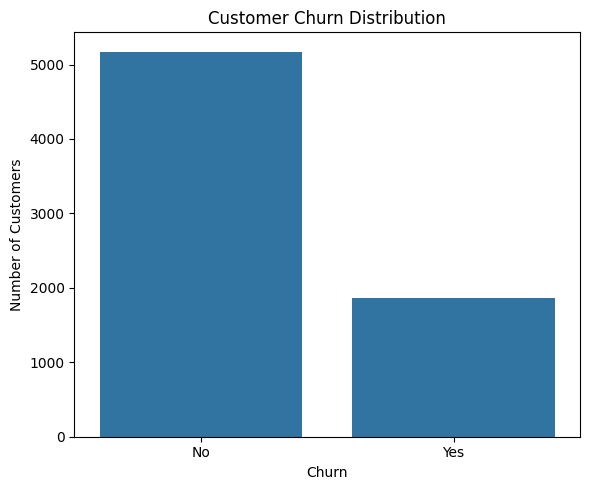

In [8]:
# ==========================================================
# Customer Churn Distribution
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../charts/churn_distribution.png",
    dpi=300
)

plt.show()

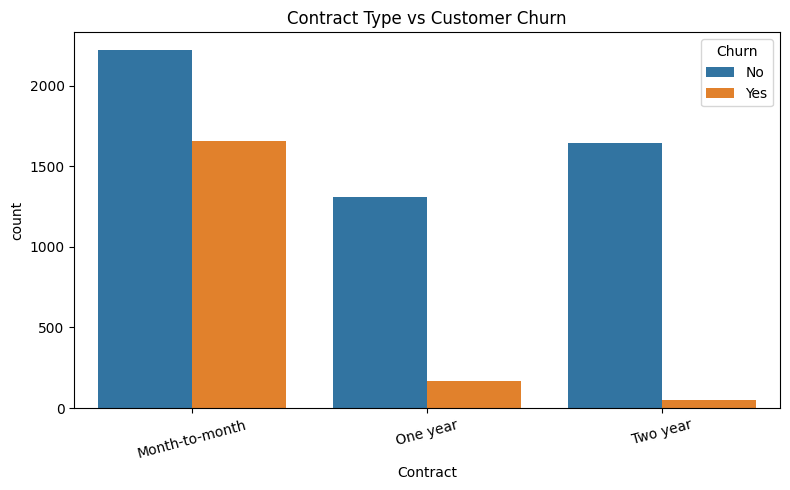

In [9]:
# ==========================================================
# Contract Type vs Churn
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Customer Churn")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../charts/contract_vs_churn.png",
    dpi=300
)

plt.show()

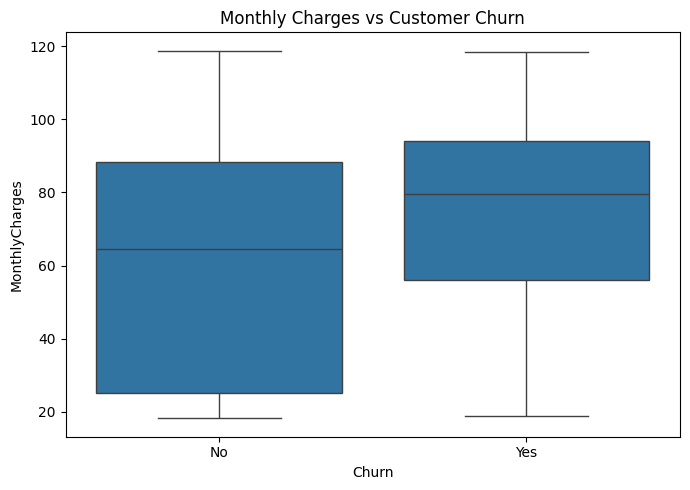

In [10]:
# ==========================================================
# Monthly Charges vs Churn
# ==========================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Customer Churn")

plt.tight_layout()

plt.savefig(
    "../charts/monthlycharges_vs_churn.png",
    dpi=300
)

plt.show()

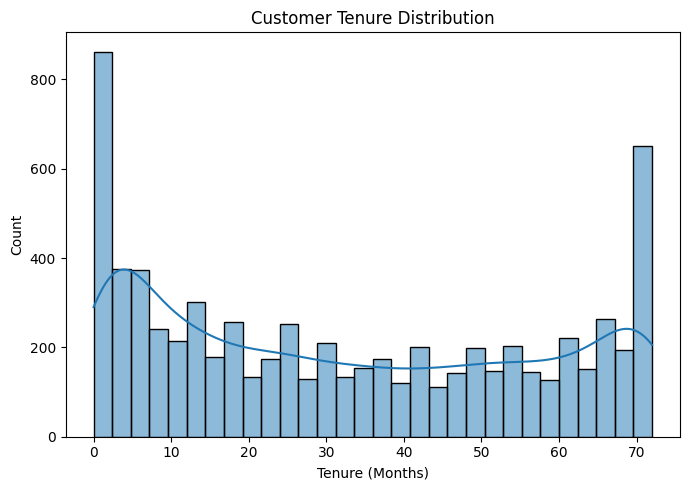

In [11]:
# ==========================================================
# Customer Tenure Distribution
# ==========================================================

plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")

plt.tight_layout()

plt.savefig(
    "../charts/tenure_distribution.png",
    dpi=300
)

plt.show()

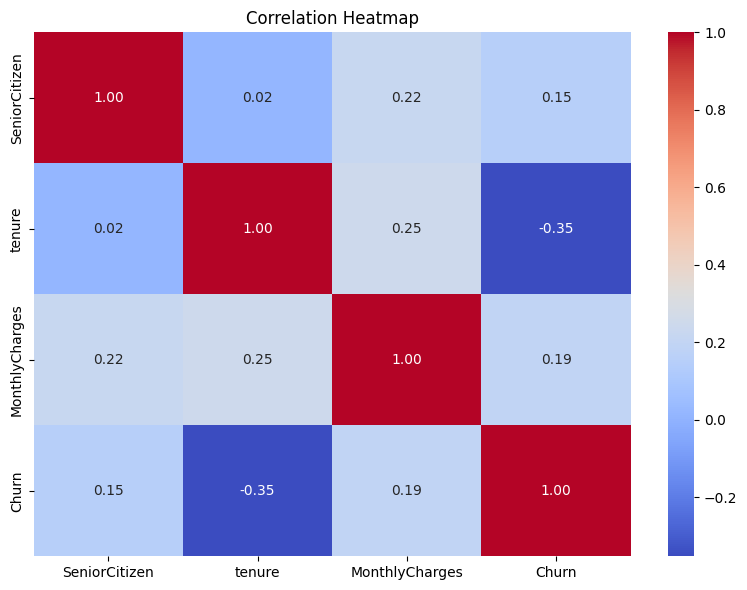

In [12]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

temp_df = df.copy()

temp_df["Churn"] = temp_df["Churn"].map({
    "Yes":1,
    "No":0
})

numeric_df = temp_df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../charts/correlation_heatmap.png",
    dpi=300
)

plt.show()

Dataset Loaded Successfully

Dataset Shape : (7043, 21)

Missing Values
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows : 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


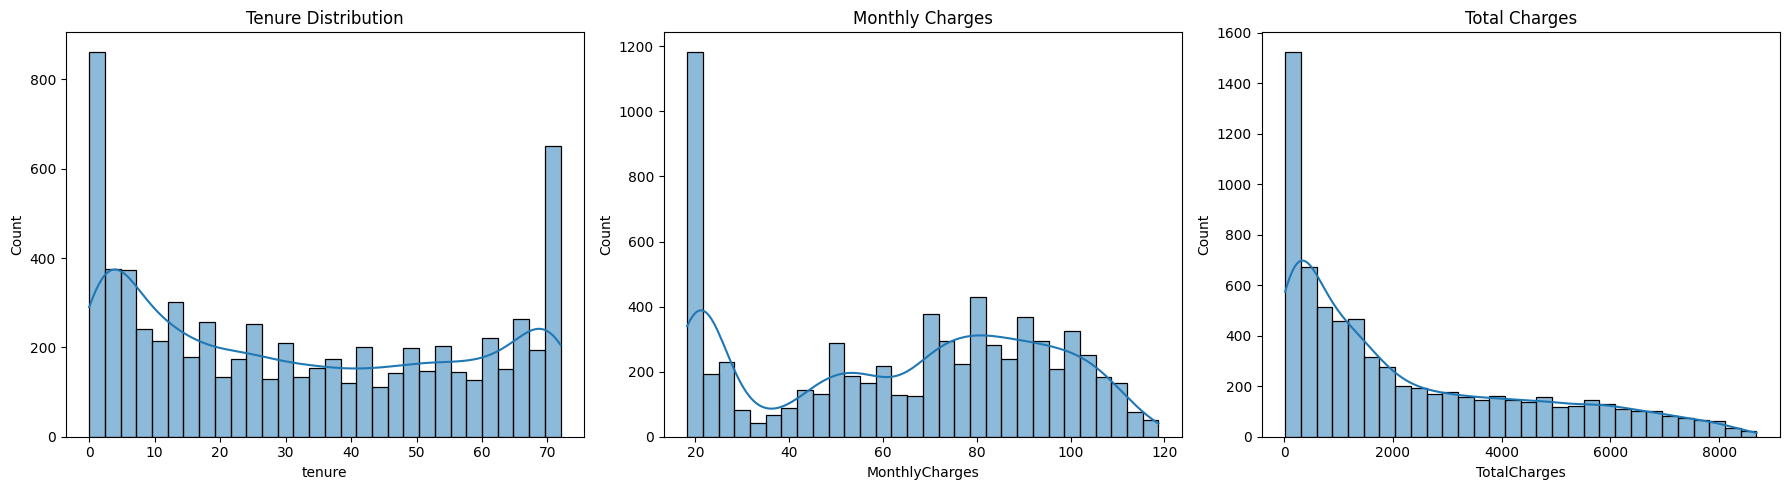

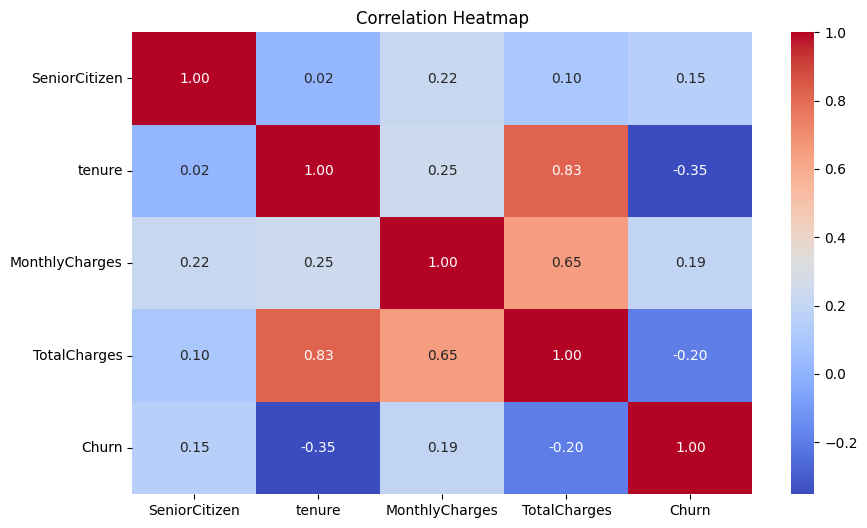

Business Insights
Total Customers : 7043
Churn Rate : 26.54%
Average Monthly Charges : 64.76
Average Tenure : 32.37 Months

Contract Distribution


Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


Payment Method Distribution


PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [13]:
# Load Original Dataset
df = pd.read_csv("../dataset/customer_churn.csv")

# Convert TotalCharges to Numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print("\nDataset Shape :", df.shape)
print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

display(df.head())

# ==========================================================
# Numerical Feature Analysis
# ==========================================================

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df["tenure"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Tenure Distribution")

sns.histplot(df["MonthlyCharges"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Monthly Charges")

sns.histplot(df["TotalCharges"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Total Charges")

plt.tight_layout()
plt.show()
# ==========================================================
# Correlation Analysis
# ==========================================================

temp_df = df.copy()

# Encode binary target
temp_df["Churn"] = temp_df["Churn"].map({"Yes":1,"No":0})

# Select Numeric Columns
numeric_df = temp_df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()
# ==========================================================
# Business Insights
# ==========================================================

print("="*60)
print("Business Insights")
print("="*60)

print(f"Total Customers : {len(df)}")

print(f"Churn Rate : {(df['Churn']=='Yes').mean()*100:.2f}%")

print(f"Average Monthly Charges : {df['MonthlyCharges'].mean():.2f}")

print(f"Average Tenure : {df['tenure'].mean():.2f} Months")

print("\nContract Distribution")

display(df["Contract"].value_counts())

print("\nPayment Method Distribution")

display(df["PaymentMethod"].value_counts())


- Phase 5: Feature Engineering

In [14]:
# ==========================================================
# PHASE 5 : FEATURE PREPARATION
# ==========================================================

import pandas as pd

# Load Processed Dataset
df = pd.read_csv("../dataset/processed_customer_churn.csv")

print("=" * 60)
print("Processed Dataset Loaded Successfully")
print("=" * 60)

print("Dataset Shape :", df.shape)

display(df.head())

# ==========================================================
# Separate Features and Target
# ==========================================================

X = df.drop("Churn", axis=1)

y = df["Churn"]

print("=" * 60)
print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape :", y.shape)
print("=" * 60)

print("\nTarget Distribution")

print(y.value_counts())
# ==========================================================
# Train Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("=" * 60)
print("Train-Test Split Completed")
print("=" * 60)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

# ==========================================================
# Dataset Verification
# ==========================================================

print("=" * 60)
print("Training Dataset Preview")
print("=" * 60)

display(X_train.head())

print()

print("=" * 60)
print("Phase 5 Completed Successfully")
print("=" * 60)


Processed Dataset Loaded Successfully
Dataset Shape : (7021, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,-1.008726,-0.440508,1.031400,-0.655475,-1.282728,-3.048725,0.829057,-1.164135,-0.997328,3.048725,...,-0.523889,-0.792144,-0.523889,-0.798109,-0.515268,-0.564137,-0.526097,1.405796,-0.542396,0
1,0.991349,-0.440508,-0.969556,-0.655475,0.062387,0.328006,-1.206190,-0.262811,-0.176347,-0.328006,...,-0.523889,-0.792144,-0.523889,-0.798109,1.940738,-0.564137,-0.526097,-0.711341,1.843671,0
2,0.991349,-0.440508,-0.969556,-0.655475,-1.241967,0.328006,0.829057,-0.365914,-0.962760,-0.328006,...,-0.523889,-0.792144,-0.523889,-0.798109,-0.515268,-0.564137,-0.526097,-0.711341,1.843671,1
3,0.991349,-0.440508,-0.969556,-0.655475,0.510759,-3.048725,-1.206190,-0.750058,-0.197869,3.048725,...,-0.523889,-0.792144,-0.523889,-0.798109,1.940738,-0.564137,-0.526097,-0.711341,-0.542396,0
4,-1.008726,-0.440508,-0.969556,-0.655475,-1.241967,0.328006,0.829057,0.194503,-0.943556,-0.328006,...,-0.523889,-0.792144,-0.523889,-0.798109,-0.515268,-0.564137,-0.526097,1.405796,-0.542396,1


Feature Matrix Shape : (7021, 30)
Target Vector Shape : (7021,)

Target Distribution
Churn
0    5164
1    1857
Name: count, dtype: int64
Train-Test Split Completed
Training Features : (5616, 30)
Testing Features  : (1405, 30)

Training Labels : (5616,)
Testing Labels  : (1405,)
Training Dataset Preview


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2624,0.991349,-0.440508,-0.969556,-0.655475,-1.241967,0.328006,-1.206190,0.194503,-0.948391,-0.328006,...,-0.640850,-0.523889,-0.792144,-0.523889,-0.798109,-0.515268,-0.564137,1.900792,-0.711341,-0.542396
2645,-1.008726,-0.440508,-0.969556,-0.655475,-0.712073,0.328006,0.829057,0.648492,-0.435424,-0.328006,...,-0.640850,-0.523889,-0.792144,-0.523889,-0.798109,-0.515268,-0.564137,1.900792,-0.711341,-0.542396
1416,0.991349,-0.440508,1.031400,1.525611,1.407502,0.328006,0.829057,0.821439,1.803029,-0.328006,...,-0.640850,-0.523889,-0.792144,-0.523889,1.252961,-0.515268,-0.564137,-0.526097,-0.711341,-0.542396
5760,0.991349,-0.440508,-0.969556,-0.655475,-1.119684,0.328006,0.829057,0.024881,-0.860450,-0.328006,...,1.560427,-0.523889,-0.792144,-0.523889,1.252961,-0.515268,-0.564137,-0.526097,-0.711341,-0.542396
2420,0.991349,-0.440508,-0.969556,-0.655475,-0.263702,0.328006,0.829057,-1.481761,-0.784804,-0.328006,...,-0.640850,1.908800,-0.792144,1.908800,-0.798109,-0.515268,-0.564137,-0.526097,1.405796,-0.542396



Phase 5 Completed Successfully


- Phase 6: Model Training & Evaluation

In [15]:
# ==========================================================
# PHASE 6 : MODEL TRAINING & EVALUATION
# ==========================================================

import joblib
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("Libraries Imported Successfully")
print("=" * 60)

Libraries Imported Successfully


In [16]:
# ==========================================================
# Train Machine Learning Models
# ==========================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "Support Vector Machine": SVC(),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )

}

results = []

trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    trained_models[name] = model
    results.append({

    "Model": name,

    "Accuracy": accuracy_score(y_test, prediction),

    "Precision": precision_score(y_test, prediction),

    "Recall": recall_score(y_test, prediction),

    "F1 Score": f1_score(y_test, prediction)

})
    

print("=" * 60)
print("All Models Trained Successfully")
print("=" * 60)

All Models Trained Successfully


In [17]:
# ==========================================================
# Model Comparison
# ==========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by= "Accuracy",
    ascending=False
).reset_index(drop=True)

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
display(results_df)



print()

print("=" * 60)
print("Best Model :", best_model_name)
print("=" * 60)

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.804982,0.675000,0.508065,0.579755
1,Logistic Regression,0.803559,0.662162,0.526882,0.586826
2,Support Vector Machine,0.799288,0.663043,0.491935,0.564815
3,Random Forest,0.777936,0.610294,0.446237,0.515528
4,KNN,0.753025,0.538700,0.467742,0.500719
5,Decision Tree,0.728826,0.487805,0.483871,0.485830



Best Model : Gradient Boosting


In [18]:
# ==========================================================
# Evaluation
# ==========================================================

y_pred = best_model.predict(X_test)

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(classification_report(y_test, y_pred))

print("=" * 60)
print("Confusion Matrix")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)

print(cm)

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1033
           1       0.68      0.51      0.58       372

    accuracy                           0.80      1405
   macro avg       0.76      0.71      0.73      1405
weighted avg       0.79      0.80      0.80      1405

Confusion Matrix
[[942  91]
 [183 189]]


In [19]:
# ==========================================================
# Save Best Model
# ==========================================================

import os
import joblib

os.makedirs("../model", exist_ok=True)

joblib.dump(
    best_model,
    "../model/churn_model.pkl"
)

print("=" * 60)
print("Best Model Saved Successfully")
print("=" * 60)

print("Model Name :", best_model_name)
print("Saved File : ../model/churn_model.pkl")

Best Model Saved Successfully
Model Name : Gradient Boosting
Saved File : ../model/churn_model.pkl
